In [1]:
import numpy as np
import matplotlib.pyplot as plt

from bar_parallax_analytic_model import bar_parallax3D

# We can test with different bar structure parameters
custom_params = {
    'sigma_x': 0.67,  # Longer bar major axis
    'sigma_y': 0.29,  # Shorter bar minor axis
    'sigma_z': 0.27,  # Thinner bar vertically
    'r_E': 8.2,       # Closer bar center
    's_max': 15.0,     # Max distance from us for averaging
    #'epsrel': 1e-6    # Relative error tolerance for integration
}

In [2]:


# Parameters
fixed_bar_angle = 25.0  # degrees
fixed_b_deg = -2.0      # degrees
longitude_range = np.arange(-15, 16)  # degrees
#solid_angle = 10/3600  # solid angle in deg^2

/var/folders/8l/p90_cj915l7dtkqz4wc5w59r0000gn/T/ipykernel_48593/2055994806.py:32: RuntimeWarning: divide by zero encountered in divide
  axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))


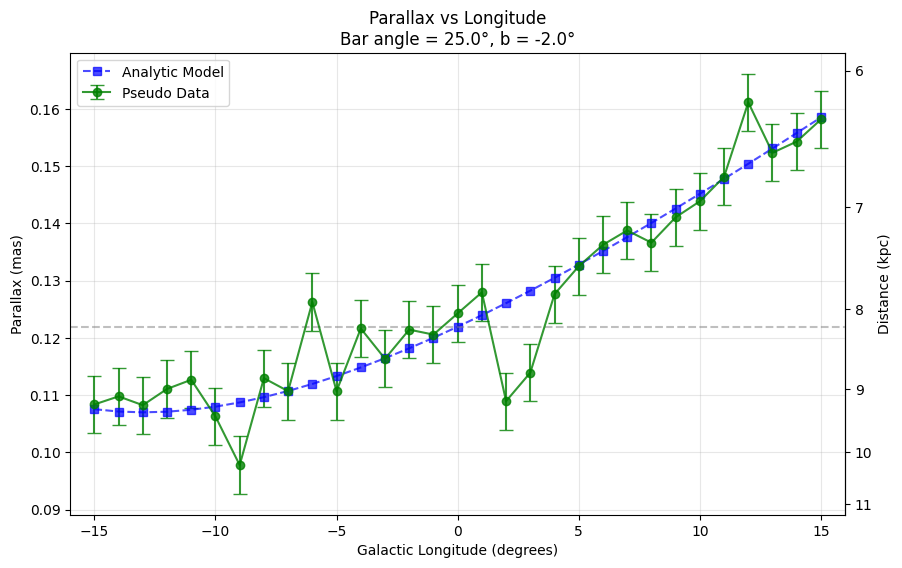

In [3]:
#Generating pseudo-data using analytic model with some noise (skip this if you have real data)
import pandas as pd

analytic_parallaxes = []
for l in longitude_range:
    #distance = compute_bar_distance(l, fixed_b_deg, fixed_bar_angle, **custom_params)
    parallax = bar_parallax3D(l, fixed_b_deg, fixed_bar_angle, **custom_params)
    analytic_parallaxes.append(parallax)


sigma = 0.005  # mas

parallax_data = np.array(analytic_parallaxes)+np.random.normal(0, sigma, size=len(analytic_parallaxes))
parallax_error = np.array([sigma]*len(analytic_parallaxes))

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.errorbar(longitude_range, parallax_data, 
            yerr=parallax_error, 
            fmt='o-', color='green', alpha=0.8, label='Pseudo Data', 
            capsize=5, markersize=6)
ax.plot(longitude_range, analytic_parallaxes, 
        's--', color='blue', alpha=0.7, label='Analytic Model', markersize=6)
ax.set_xlabel('Galactic Longitude (degrees)')
ax.set_ylabel(f'Parallax (mas)')
ax.set_title(f'Parallax vs Longitude\nBar angle = {fixed_bar_angle}°, b = {fixed_b_deg}°')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(-16, 16)
ax.axhline(1/8.2, color='gray', linestyle='--', alpha=0.5)

axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))
axsec.set_ylabel('Distance (kpc)')

#plt.savefig('bar_angle_analytic_model_comparison.pdf', dpi=300)
plt.show()

100%|██████████| 2000/2000 [12:23<00:00,  2.69it/s]


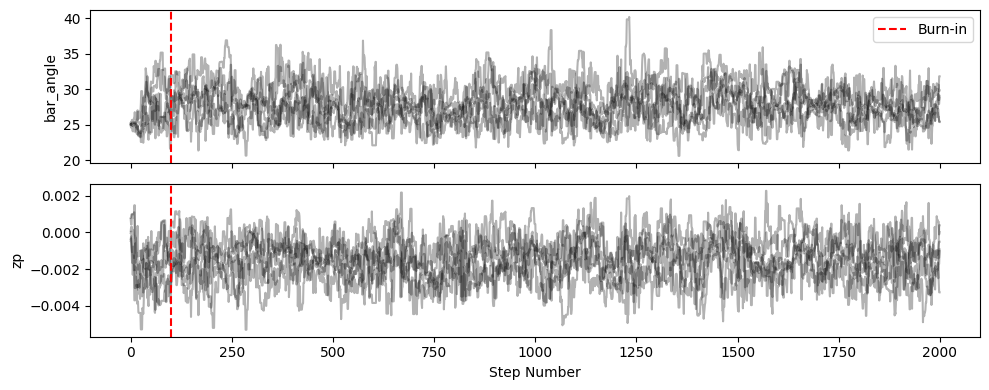

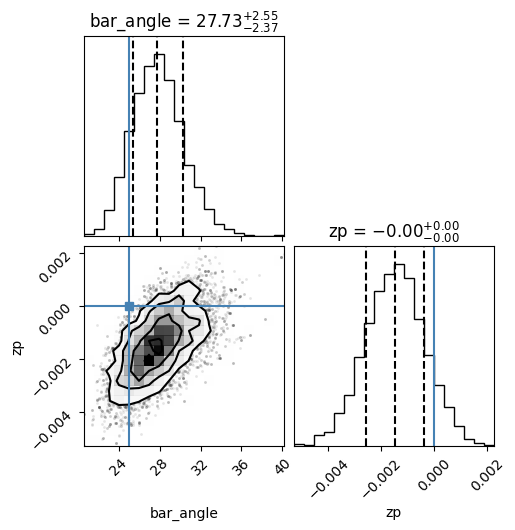

/Users/himanshuverma/Documents/MyHome/MyHomeLSU/Research/Topics/Roman/GaiaBarAngle/Bar-Angle-Calculator/bar_angle_fitter.py:287: RuntimeWarning: divide by zero encountered in divide
  axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))


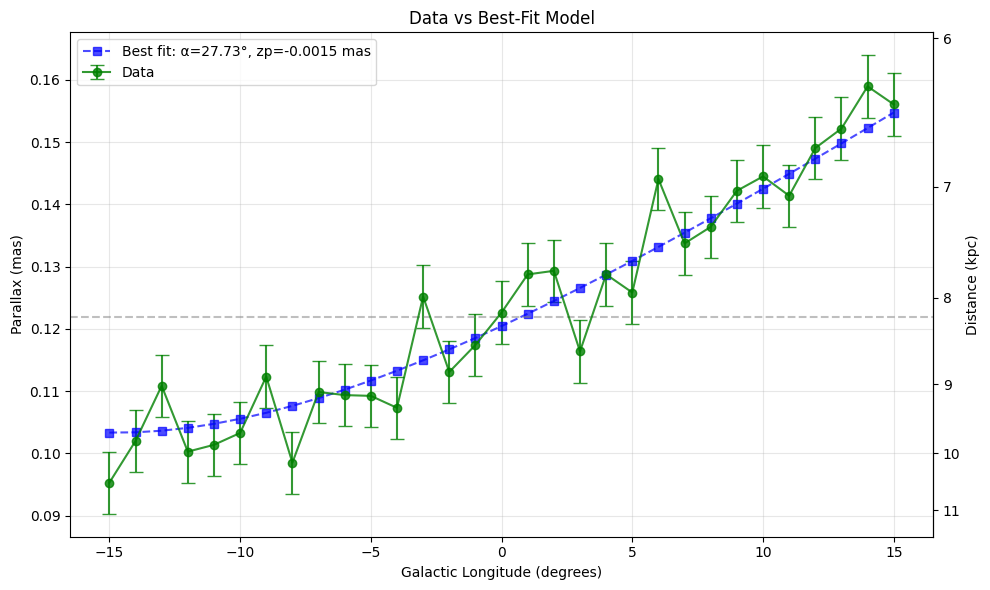

Bar angle: 27.73° $\pm$ 2.50°
Zero-point: -0.0015 $\pm$ 0.0011 mas


In [4]:
from bar_angle_fitter import BarAngleFitter

# Create fitter with your data
fitter = BarAngleFitter(
    parallax_data=parallax_data,
    parallax_error=parallax_error,
    l_values=longitude_range,
    b_values=fixed_b_deg,
    model_params=custom_params,
    fit_params=['bar_angle', 'zp']
)

# Run MCMC
fitter.run_mcmc(n_walkers=6, n_steps=2000, n_burn=100)

# Plot all results (chains, corner plot, fit)
fitter.plot_results(truths=[fixed_bar_angle, 0.0])

# Get numerical results
results = fitter.get_results()
print(f"Bar angle: {results['bar_angle']['median']:.2f}° $\\pm$ {results['bar_angle']['std']:.2f}°")
print(f"Zero-point: {results['zp']['median']:.4f} $\\pm$ {results['zp']['std']:.4f} mas")

100%|██████████| 2000/2000 [12:37<00:00,  2.64it/s]


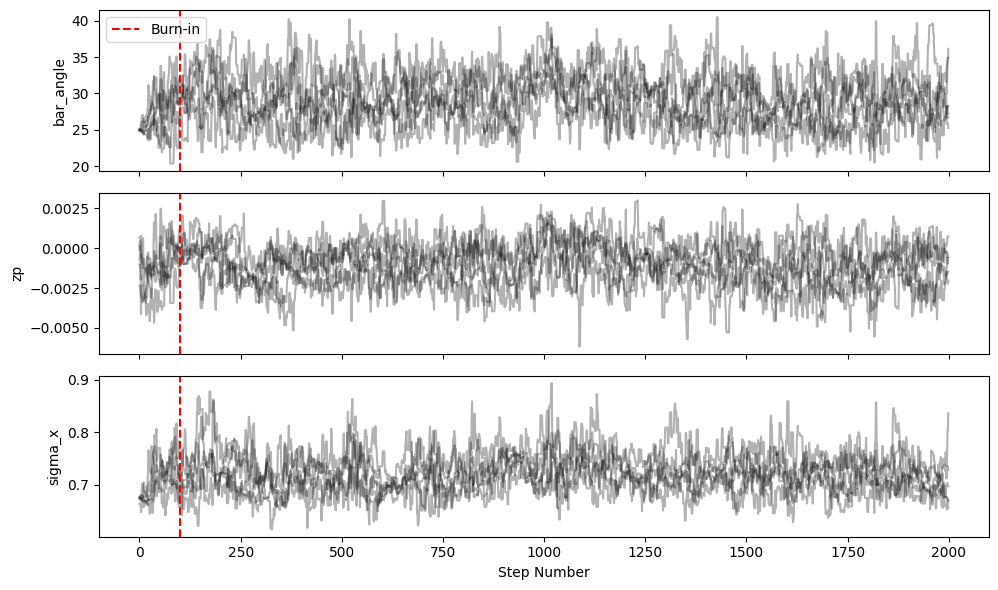

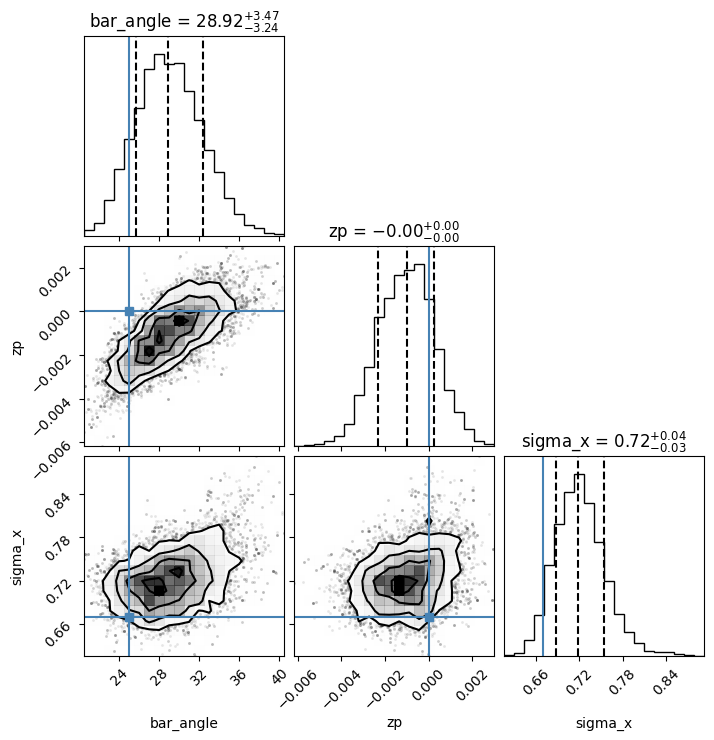

/Users/himanshuverma/Documents/MyHome/MyHomeLSU/Research/Topics/Roman/GaiaBarAngle/Bar-Angle-Calculator/bar_angle_fitter.py:287: RuntimeWarning: divide by zero encountered in divide
  axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))


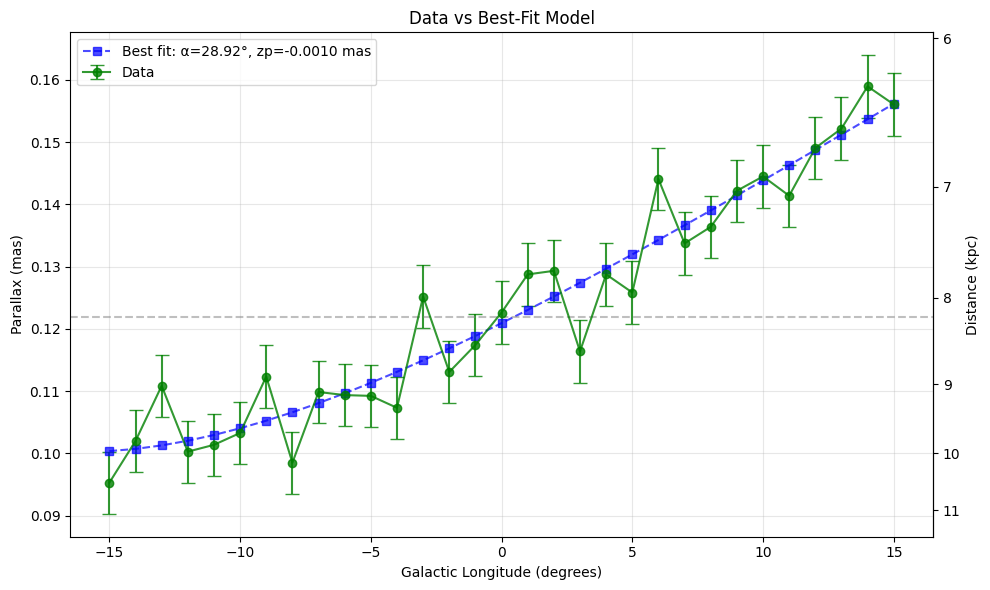

Bar angle: 28.92° $\pm$ 3.29°
Zero-point: -0.0010 $\pm$ 0.0013 mas


In [5]:
model_params = {
    'sigma_x': {'mean': 0.67, 'std': 0.1},  # Gaussian prior
    'sigma_y': 0.29,  # Fixed
    'sigma_z': 0.27,  # Fixed
    'r_E': 8.2,       # Fixed
    's_max': 15.0
}

fitter = BarAngleFitter(
    parallax_data=parallax_data,
    parallax_error=parallax_error,
    l_values=longitude_range,
    b_values=fixed_b_deg,
    model_params=model_params,
    fit_params=['bar_angle', 'zp', 'sigma_x']
)


# Run MCMC
fitter.run_mcmc(n_walkers=6, n_steps=2000, n_burn=100)

# Plot all results (chains, corner plot, fit)
#fitter.plot_results(truths=[fixed_bar_angle, 0.0])
fitter.plot_results(truths=[fixed_bar_angle, 0.0, 0.67])


# Get numerical results
results = fitter.get_results()
print(f"Bar angle: {results['bar_angle']['median']:.2f}° $\\pm$ {results['bar_angle']['std']:.2f}°")
print(f"Zero-point: {results['zp']['median']:.4f} $\\pm$ {results['zp']['std']:.4f} mas")

100%|██████████| 2000/2000 [24:10<00:00,  1.38it/s]


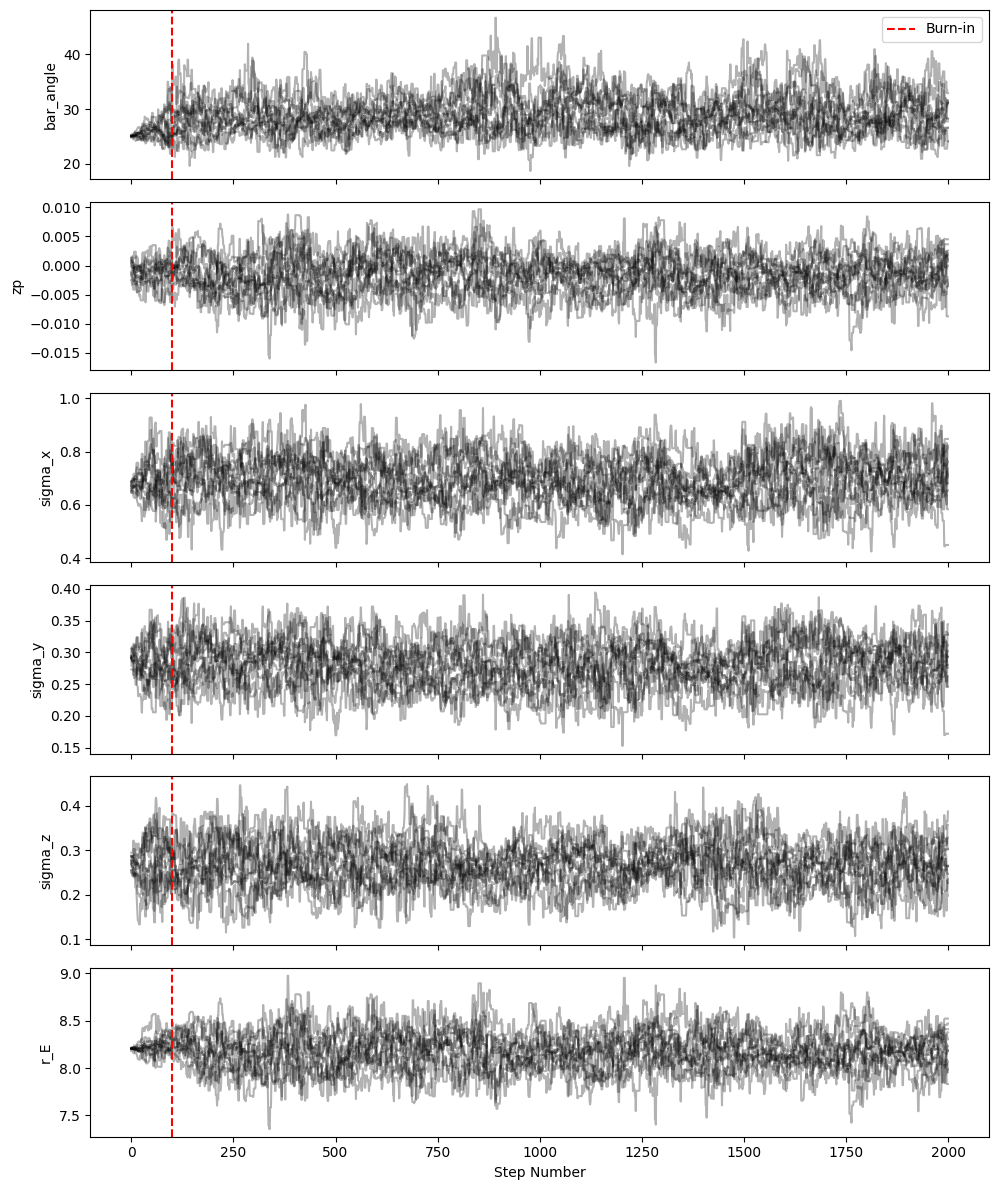

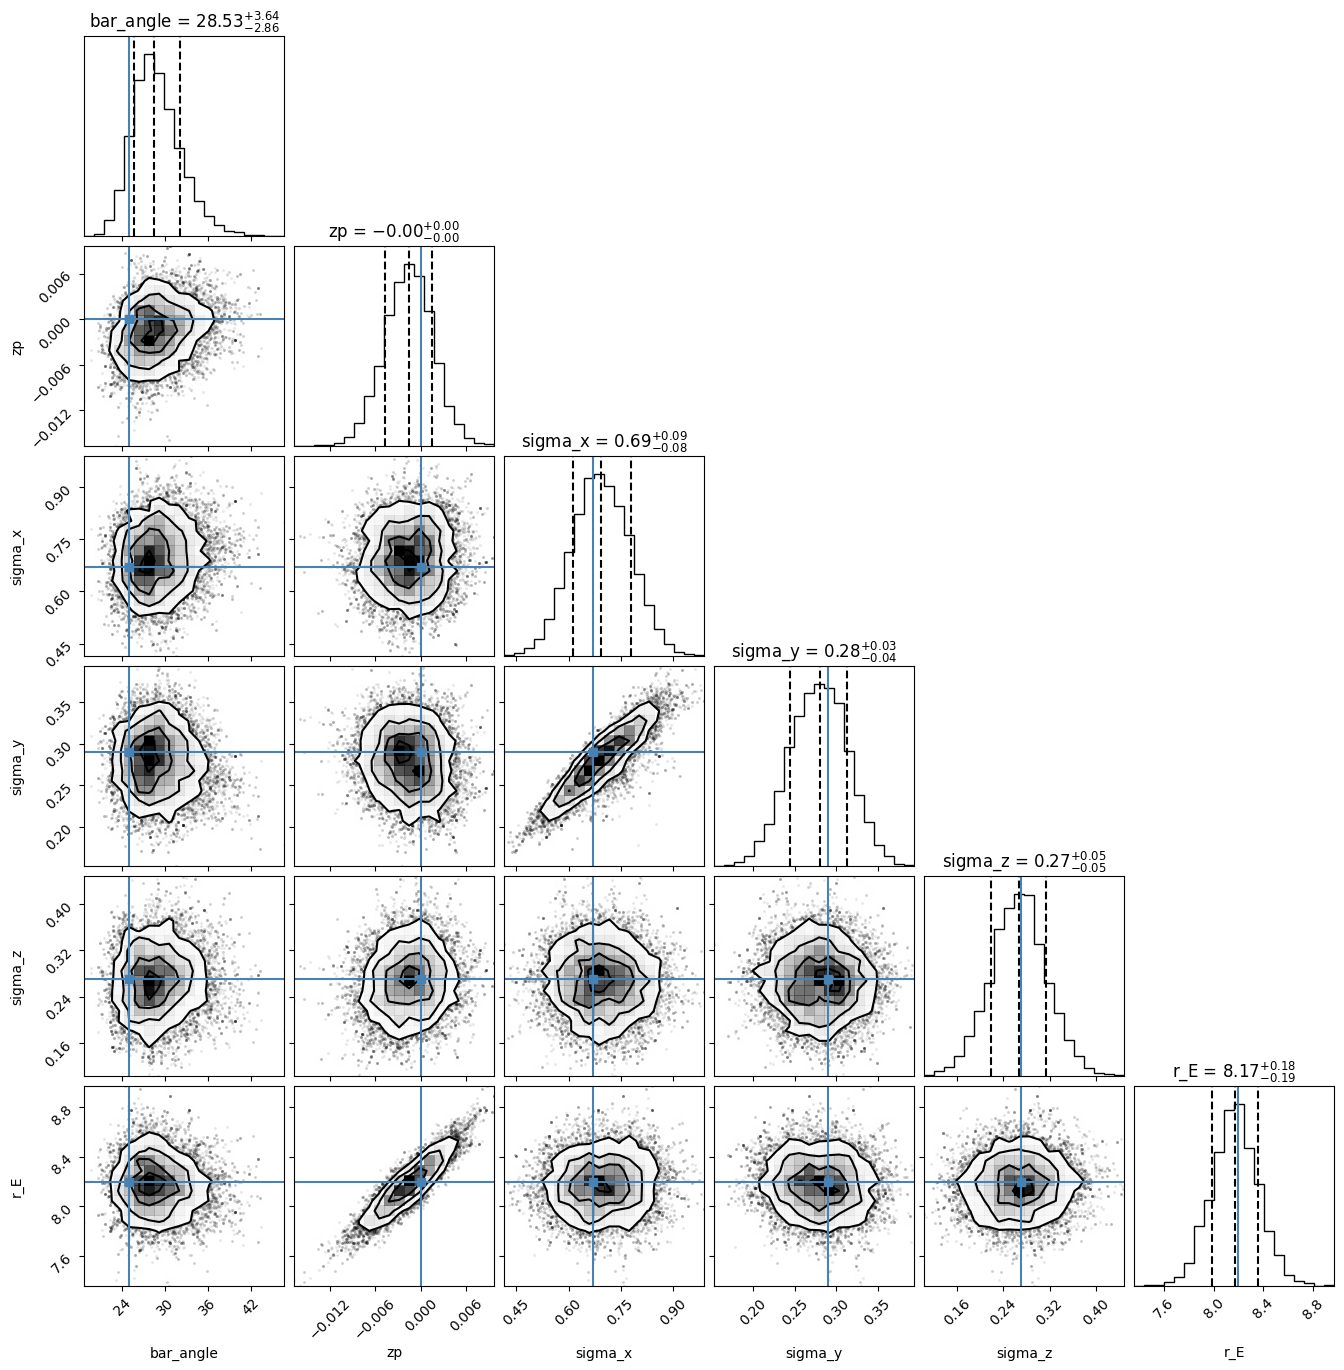

/Users/himanshuverma/Documents/MyHome/MyHomeLSU/Research/Topics/Roman/GaiaBarAngle/Bar-Angle-Calculator/bar_angle_fitter.py:287: RuntimeWarning: divide by zero encountered in divide
  axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))


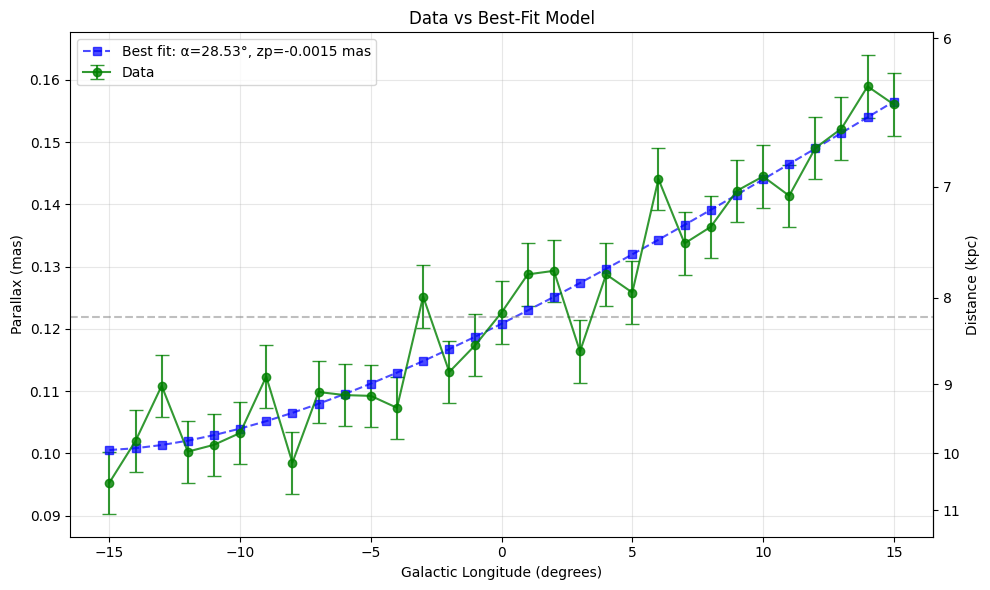

Bar angle: 28.53° $\pm$ 3.36°
Zero-point: -0.0015 $\pm$ 0.0032 mas


In [6]:
model_params = {
    'sigma_x': {'mean': 0.67, 'std': 0.1},
    'sigma_y': {'mean': 0.29, 'std': 0.05},
    'sigma_z': {'mean': 0.27, 'std': 0.05},
    'r_E': {'mean': 8.2, 'std': 0.2},
    's_max': 15.0  # Always fixed
}

fitter = BarAngleFitter(
    parallax_data=parallax_data,
    parallax_error=parallax_error,
    l_values=longitude_range,
    b_values=fixed_b_deg,
    model_params=model_params,
    fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
)

# Run MCMC
fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100)

# Plot all results (chains, corner plot, fit)

fitter.plot_results(truths=[25.0, 0.0, 0.67, 0.29, 0.27, 8.2])
# Get numerical results
results = fitter.get_results()
print(f"Bar angle: {results['bar_angle']['median']:.2f}° $\\pm$ {results['bar_angle']['std']:.2f}°")
print(f"Zero-point: {results['zp']['median']:.4f} $\\pm$ {results['zp']['std']:.4f} mas")

100%|██████████| 2000/2000 [14:58<00:00,  2.23it/s]


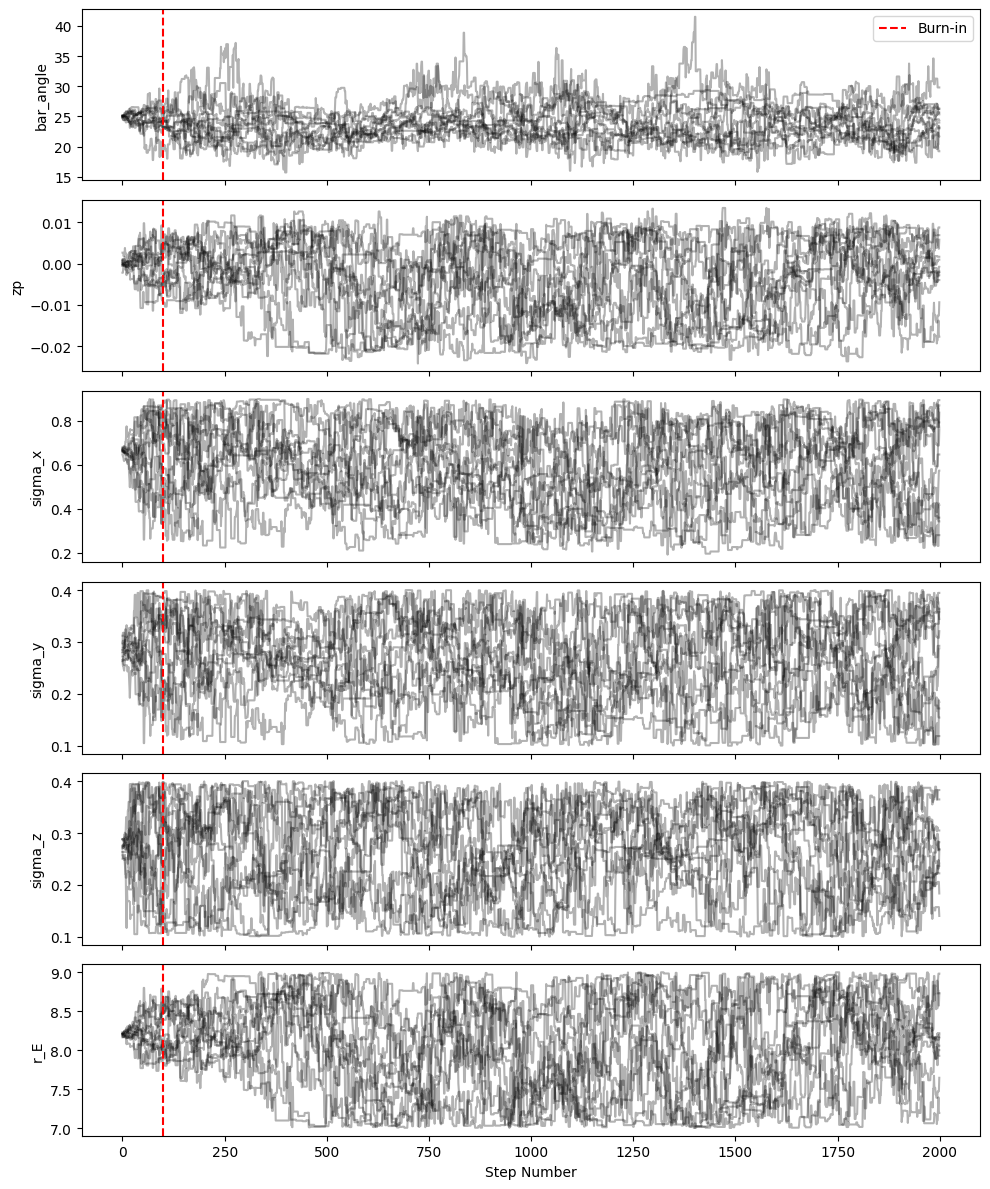

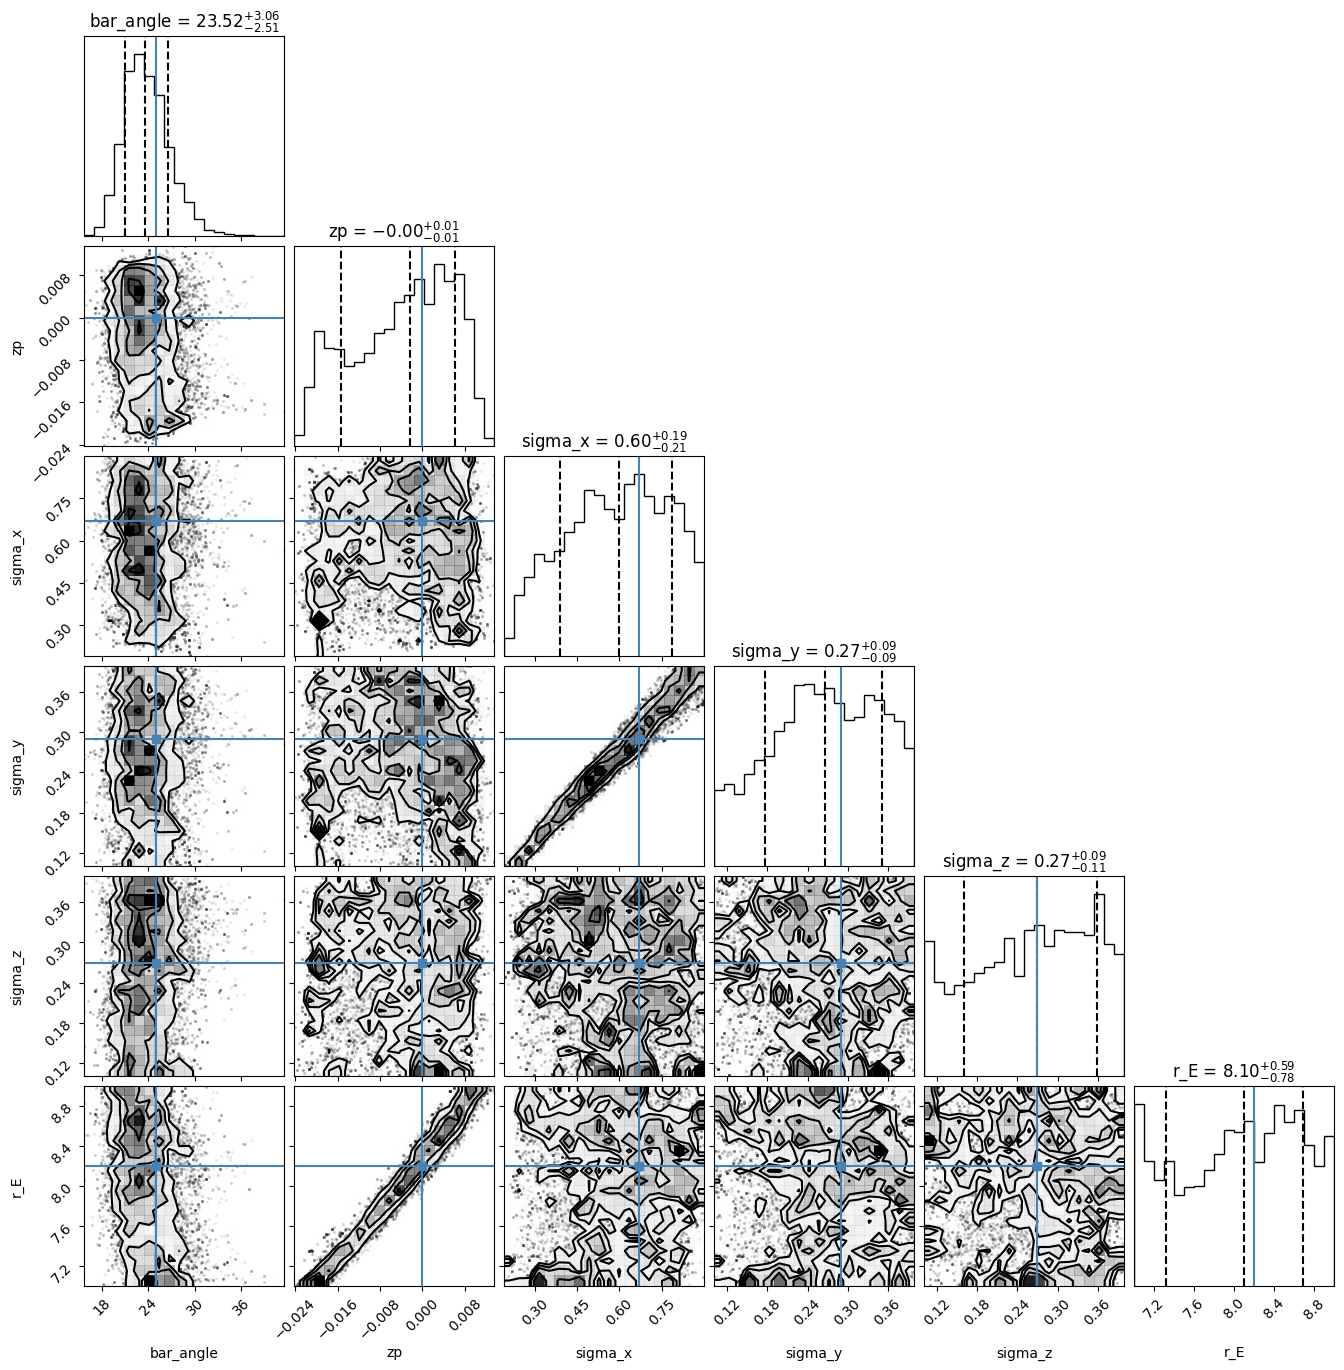

/Users/himanshuverma/Documents/MyHome/MyHomeLSU/Research/Topics/Roman/GaiaBarAngle/Bar-Angle-Calculator/bar_angle_fitter.py:294: RuntimeWarning: divide by zero encountered in divide
  axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))


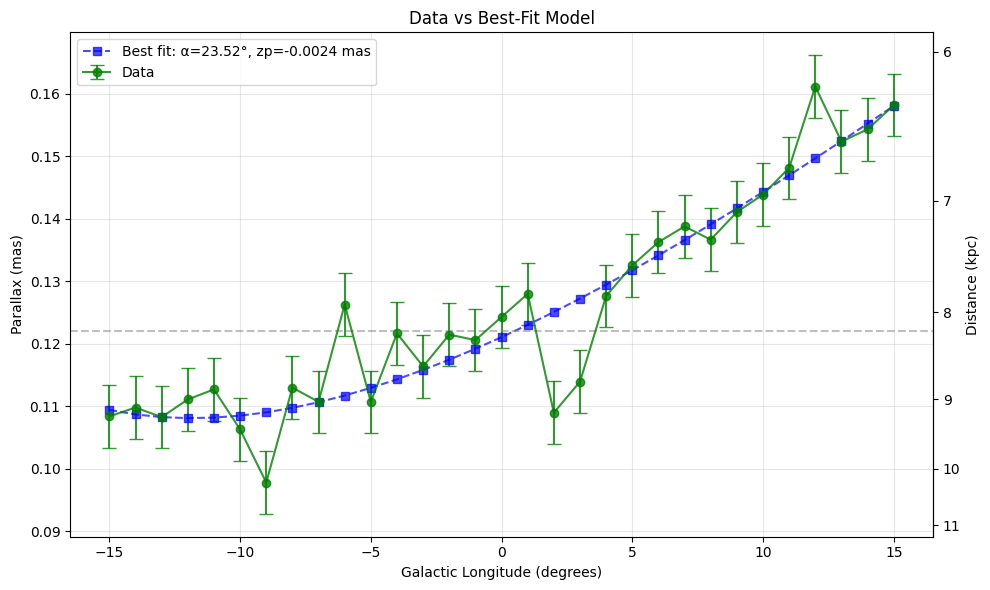

Bar angle: 23.52° $\pm$ 2.91°
Zero-point: -0.0024 $\pm$ 0.0092 mas


In [4]:
from bar_angle_fitter import BarAngleFitter

model_params = {
    'sigma_x': 0.67,
    'sigma_y': 0.29,
    'sigma_z': 0.27,
    'r_E': 8.2,
    's_max': 15.0  # Always fixed
}

fitter = BarAngleFitter(
    parallax_data=parallax_data,
    parallax_error=parallax_error,
    l_values=longitude_range,
    b_values=fixed_b_deg,
    model_params=model_params,
    fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
)

# Run MCMC
fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100, priors_range={'sigma_x': (0.1, 0.9), 'sigma_y': (0.1, 0.4), 'sigma_z': (0.1, 0.4), 'r_E': (7, 9)})

# Plot all results (chains, corner plot, fit)

fitter.plot_results(truths=[25.0, 0.0, 0.67, 0.29, 0.27, 8.2])
# Get numerical results
results = fitter.get_results()
print(f"Bar angle: {results['bar_angle']['median']:.2f}° $\\pm$ {results['bar_angle']['std']:.2f}°")
print(f"Zero-point: {results['zp']['median']:.4f} $\\pm$ {results['zp']['std']:.4f} mas")

100%|██████████| 2000/2000 [17:42<00:00,  1.88it/s]


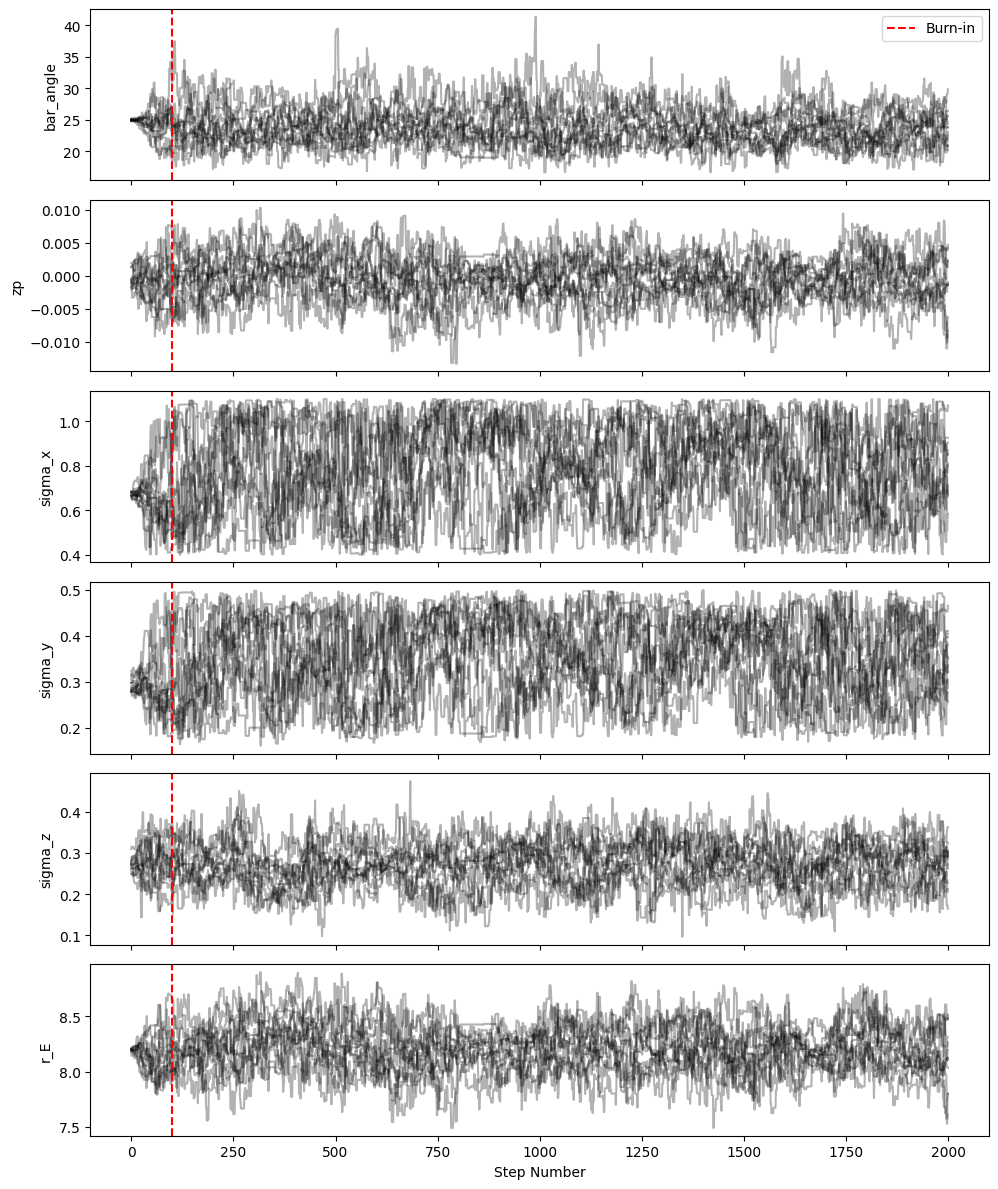

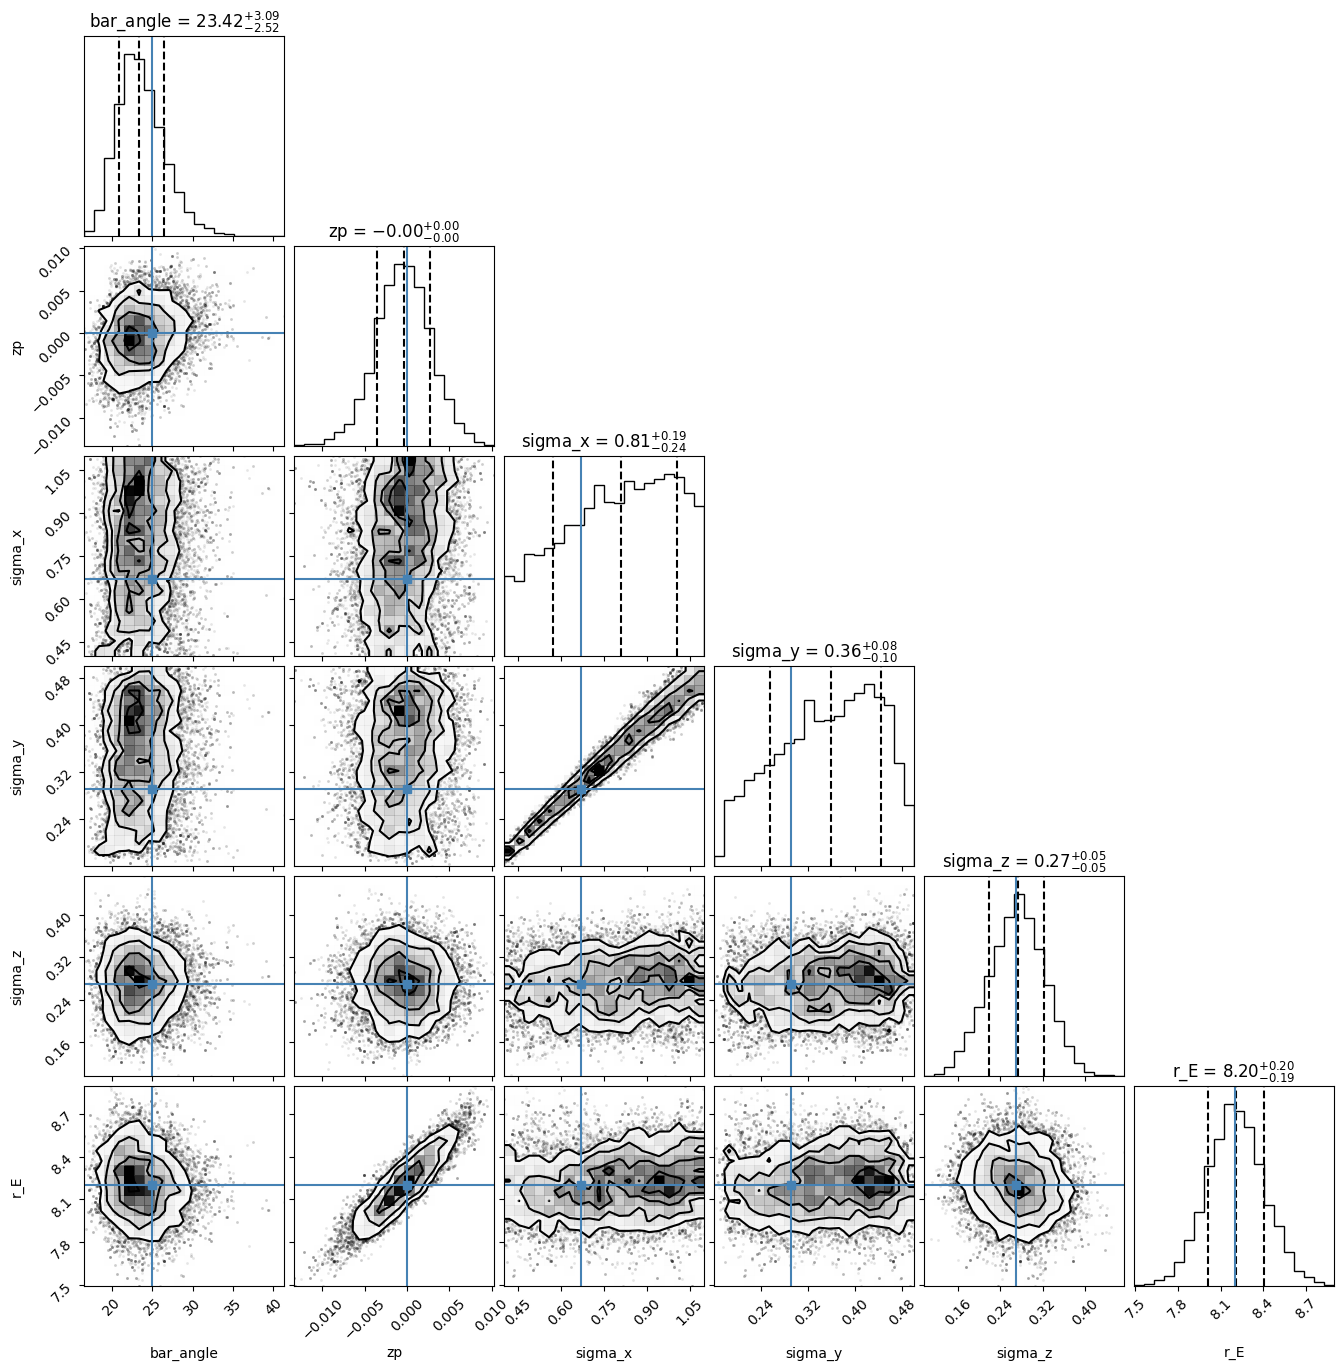

/Users/himanshuverma/Documents/MyHome/MyHomeLSU/Research/Topics/Roman/GaiaBarAngle/Bar-Angle-Calculator/bar_angle_fitter.py:294: RuntimeWarning: divide by zero encountered in divide
  axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))


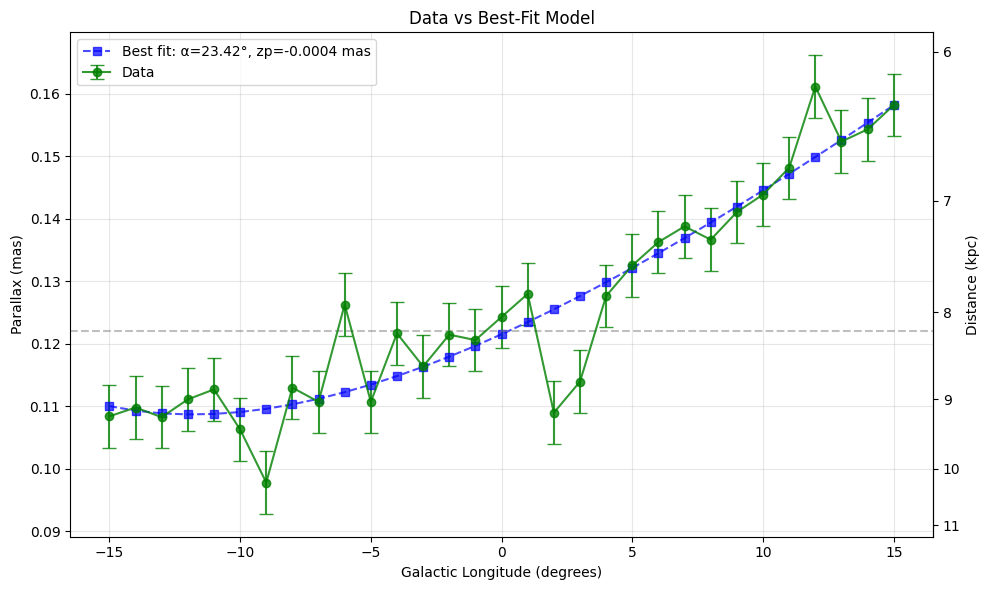

Bar angle: 23.42° $\pm$ 2.89°
Zero-point: -0.0004 $\pm$ 0.0032 mas


In [8]:
from bar_angle_fitter import BarAngleFitter

model_params = {
    'sigma_x': 0.67,
    'sigma_y': 0.29,
    'sigma_z': {'mean': 0.27, 'std': 0.05},
    'r_E': {'mean': 8.2, 'std': 0.2},
    's_max': 15.0  # Always fixed
}

fitter = BarAngleFitter(
    parallax_data=parallax_data,
    parallax_error=parallax_error,
    l_values=longitude_range,
    b_values=fixed_b_deg,
    model_params=model_params,
    fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
)

# Run MCMC
fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100, priors_range={'sigma_x': (0.4, 1.1), 'sigma_y': (0.1, 0.5)})

# Plot all results (chains, corner plot, fit)

fitter.plot_results(truths=[25.0, 0.0, 0.67, 0.29, 0.27, 8.2])
# Get numerical results
results = fitter.get_results()
print(f"Bar angle: {results['bar_angle']['median']:.2f}° $\\pm$ {results['bar_angle']['std']:.2f}°")
print(f"Zero-point: {results['zp']['median']:.4f} $\\pm$ {results['zp']['std']:.4f} mas")

# to do
- No prior run
- Running with prior on rE, sigma_z
- Run with priors on sigma_x, sigma_y, sigma_z, rE


- Running with individual strips (i.e. b=fixed)
    - No prior run
    - Running with prior on rE, sigma_z
    - Run with priors on sigma_x, sigma_y, sigma_z, rE

- Run with all combination of (l,b) with sigma_z free

- Origin of correlation needs to be explained/examined



- Running with all combination of (l,b)
    - No prior run
    - Running with prior on rE, sigma_z
    - Run with priors on sigma_x, sigma_y, sigma_z, rE


- Store chi2 and dof for each run
- Maybe store chains and then derive 
    - Compute covariance matrix of the parameters as well.
    - best fit
